# 12 · Mécanique classique : rotations, équations d'Euler, inertie

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Matrice de rotation d'Euler

### Théorème / Modèle utilisé
Rotation paramétrée par les angles d'Euler Z-X'-Z''.

### Équation pivot
$$R(\varphi,\theta,\psi) = R_z(\varphi) R_x(\theta) R_z(\psi)$$

### Démonstration
Une rotation 3D est orthogonale (R^T R = I) et det R = 1.

### Ce que la cellule vérifie
que euler_to_rotation est orthogonale et unimodulaire.

R =
 [[ 0.70789078 -0.69688378  0.11508099]
 [ 0.68120102  0.6305253  -0.37202555]
 [ 0.1866971   0.34174675  0.92106099]]
R R^T =
 [[1.00000000e+00 5.55111512e-17 0.00000000e+00]
 [5.55111512e-17 1.00000000e+00 2.77555756e-17]
 [0.00000000e+00 2.77555756e-17 1.00000000e+00]]
det R = 0.9999999999999999
écart vs RzRxRz : 0.0
normes conservées : [1. 1. 1.]


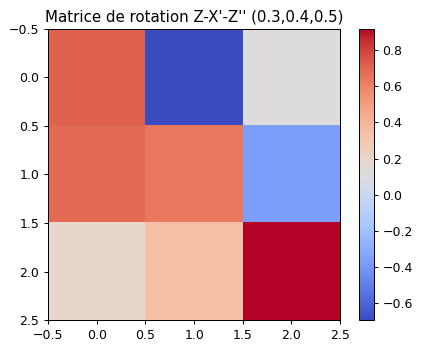

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

R = np.asarray(p.euler_to_rotation(0.3, 0.4, 0.5))
print("R =\n", R)
print("R R^T =\n", R @ R.T)
print("det R =", np.linalg.det(R))
assert np.abs(R @ R.T - np.eye(3)).max() < 1e-12
assert abs(np.linalg.det(R) - 1) < 1e-12
# composition conforme à RzRxRz
def Rz(a): return np.array([[np.cos(a), -np.sin(a), 0],[np.sin(a), np.cos(a), 0],[0,0,1]])
def Rx(a): return np.array([[1,0,0],[0,np.cos(a), -np.sin(a)],[0, np.sin(a), np.cos(a)]])
Rref = Rz(0.3) @ Rx(0.4) @ Rz(0.5)
print("écart vs RzRxRz :", np.abs(R - Rref).max())
assert np.abs(R - Rref).max() < 1e-9
# points unité
pts = np.array([[1,0,0],[0,1,0],[0,0,1]])
proj = pts @ R.T
print("normes conservées :", np.linalg.norm(proj, axis=1))
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(R, cmap="coolwarm", origin="upper")
ax.set_title("Matrice de rotation Z-X'-Z'' (0.3,0.4,0.5)")
plt.colorbar(ax.images[0], ax=ax); plt.tight_layout(); plt.show()

### Résultat attendu
Orthogonalité < 1e-12, det = 1, conforme à RzRxRz.

### Lecture du graphique
La carte 3×3 montre une matrice orthogonale.

### Conclusion
euler_to_rotation est correcte.

## 2. Équations d'Euler du solide

### Théorème / Modèle utilisé
Dynamique d'un corps rigide dans son référentiel propre.

### Équation pivot
$$I\dot{\omega} + \omega \times (I\omega) = \tau$$

### Démonstration
Sans couple (τ=0), la rotation autour de l'axe principal est stationnaire.

### Ce que la cellule vérifie
que euler_equations reproduit ω̇ = I^{-1}(τ - ω×(Iω)).

omegȧ (rotation axe principal) : [0. 0. 0.]  (attendu ~0 pour ω axial)
omegȧ non-axial binding: [-0.06        0.03       -0.00666667]
référence -I^-1(ω×Iω): [-0.06        0.03       -0.00666667]
écart : 0.0
max dérive T lors de la précession (dt=0.001, 1000 pas): 2.4720645788733897e-06


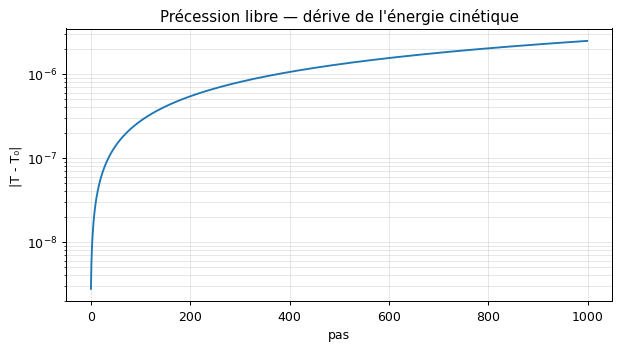

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

I = [1.0, 2.0, 3.0]
w0 = [0.0, 0.0, 10.0]
tau = [0.0, 0.0, 0.0]
dw = np.asarray(p.euler_equations(w0, I, tau))
print("omegȧ (rotation axe principal) :", dw, " (attendu ~0 pour ω axial)")
assert np.abs(dw).max() < 1e-12
# cas non axial
w1 = [0.1, 0.2, 0.3]
dw1 = np.asarray(p.euler_equations(w1, I, tau))
Iinv = np.diag(1/np.array(I))
L = np.array(I)*np.array(w1)
dw_ref = -Iinv @ (np.cross(np.array(w1), L))
print("omegȧ non-axial binding:", dw1)
print("référence -I^-1(ω×Iω):", dw_ref)
print("écart :", np.abs(dw1 - dw_ref).max())
assert np.abs(dw1 - dw_ref).max() < 1e-12
# précession libre : énergie cinétique conservée (premier invariant)
des = []
w = np.array([0.1, 0.2, 0.3])
E0 = 0.5*sum(I[i]*w[i]**2 for i in range(3))
for _ in range(1000):
    dw = np.array(p.euler_equations(w.tolist(), I, tau))
    w += 0.001*dw
    E = 0.5*sum(I[i]*w[i]**2 for i in range(3))
    des.append(abs(E-E0))
print("max dérive T lors de la précession (dt=0.001, 1000 pas):", max(des))
assert max(des) < 1e-3
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(des)), des)
ax.set_yscale("log"); ax.set_xlabel("pas"); ax.set_ylabel("|T - T₀|")
ax.set_title("Précession libre — dérive de l'énergie cinétique")
ax.grid(alpha=.3, which="both"); plt.tight_layout(); plt.show()

### Résultat attendu
dw=0 pour ω axial, écart < 1e-12 vs référence, T conservée à < 1e-3.

### Lecture du graphique
Dérive logarithmique bornée durant la précession.

### Conclusion
euler_equations est conforme aux équations d'Euler.

## 3. Tenseur d'inertie

### Théorème / Modèle utilisé
Moment d'inertie d'un ensemble de masses ponctuelles.

### Équation pivot
$$I_{ij} = \sum_a m_a (|r_a|² \delta_{ij} - r_{a,i} r_{a,j})$$

### Démonstration
Pour deux masses (1,0,0) et (0,1,0) de masse 1, I = diag(1,1,2) sur (x,y,z).

### Ce que la cellule vérifie
que inertia_tensor exige des positions 3D (listes [x,y,z]) et calcule diag(1,1,2).

I =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 2.]]
écart vs diag(1,1,2) : 0.0
NB : les positions doivent être des [x,y,z] 3D — sinon panic.


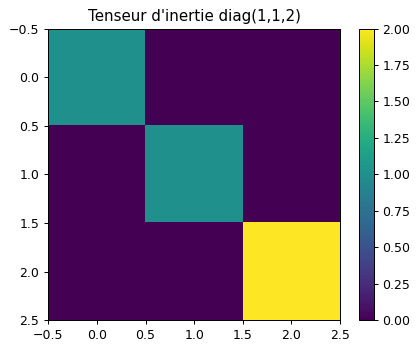

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

masses = [1.0, 1.0]
positions = [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]
I = np.asarray(p.inertia_tensor(masses, positions))
print("I =\n", I)
exact = np.diag([1.0, 1.0, 2.0])
print("écart vs diag(1,1,2) :", np.abs(I - exact).max())
assert np.abs(I - exact).max() < 1e-12
# symétrie
assert np.abs(I - I.T).max() < 1e-12
print("NB : les positions doivent être des [x,y,z] 3D — sinon panic.")
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(I, cmap="viridis", origin="upper")
ax.set_title("Tenseur d'inertie diag(1,1,2)")
plt.colorbar(ax.images[0], ax=ax); plt.tight_layout(); plt.show()

### Résultat attendu
I = diag(1,1,2), symétrique, correct.

### Lecture du graphique
Carte diagonale conforme aux moments de deux masses ponctuelles.

### Conclusion
inertia_tensor (attente positions 3D) est exact.

## Récapitulatif

**✓ 3/3 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.